In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/preprocessing_practice_dataset.csv')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df.isnull()

,Employee_ID,Age,Gender,Department,Education,Experience_Years,Monthly_Salary,Performance_Rating,City,Attrition
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False
97,False,False,False,True,False,False,False,False,False,False
98,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Age,10
Gender,0
Department,10
Education,10
Experience_Years,0
Monthly_Salary,10
Performance_Rating,0
City,10
Attrition,0


In [ ]:
df['Age_imputed_mean'] = df['Age'].fillna(df['Age']).mean()

In [ ]:
df['Monthly_Salary_imputed_mean'] = df['Monthly_Salary'].fillna(df['Monthly_Salary']).mean()

/tmp/ipykernel_5235/2115333283.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df , x='Age' ,y='Monthly_Salary',palette='pastel')


Text(0, 0.5, 'Monthly_Salary')

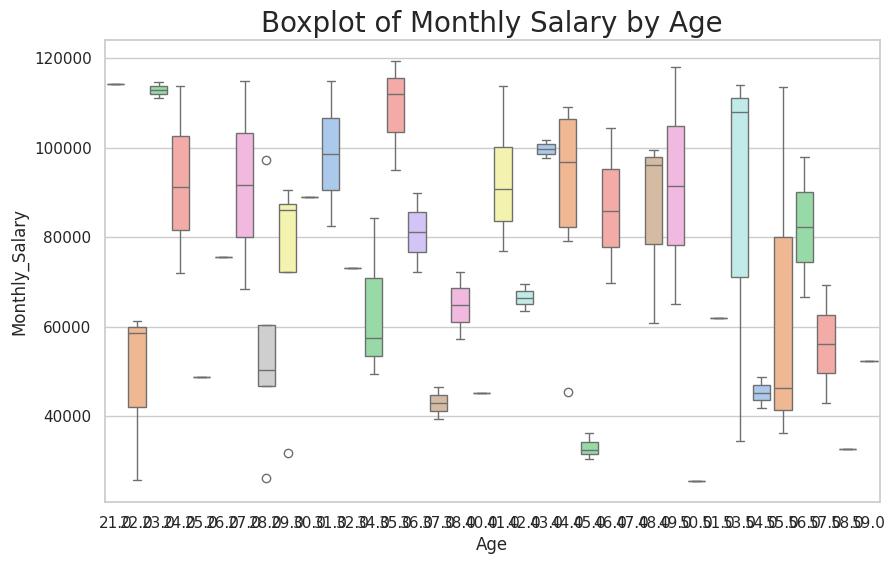

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.boxplot(data=df , x='Age' ,y='Monthly_Salary',palette='pastel')
plt.title('Boxplot of Monthly Salary by Age',fontsize=20)
plt.xlabel('Age',fontsize=12)
plt.ylabel('Monthly_Salary',fontsize=12)

/tmp/ipykernel_5235/2574204213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df , x='City' ,y='Monthly_Salary',palette='pastel')


Text(0, 0.5, 'Monthly_Salary')

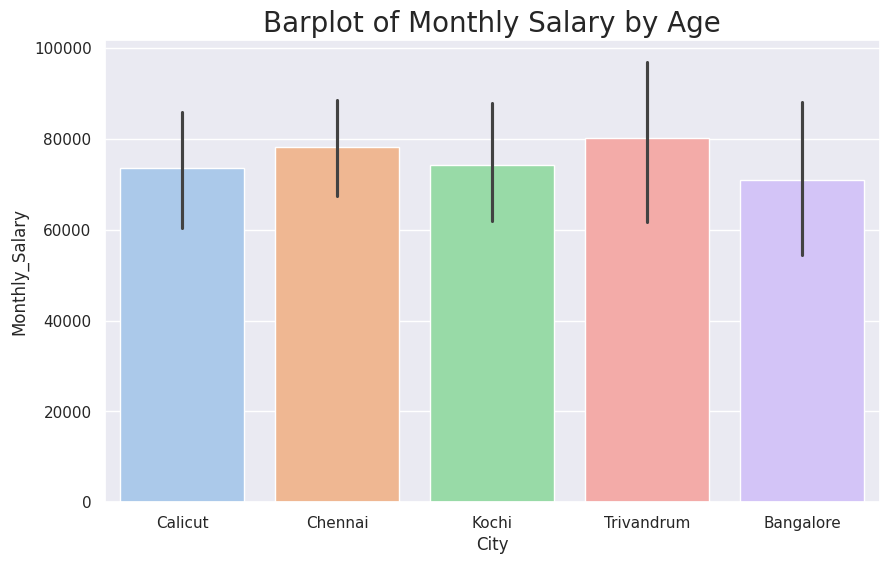

In [ ]:
sns.set(style='darkgrid')
plt.figure(figsize=(10,6))
sns.barplot(data=df , x='City' ,y='Monthly_Salary',palette='pastel')
plt.title('Barplot of Monthly Salary by Age',fontsize=20)
plt.xlabel('City',fontsize=12)
plt.ylabel('Monthly_Salary',fontsize=12)

In [ ]:
df['City_imputed_mode']=df['City'].fillna(df['City']).mode()

/tmp/ipykernel_5235/1358402067.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df , x='Age' ,y='Monthly_Salary',palette='pastel')


Text(0, 0.5, 'Monthly_Salary')

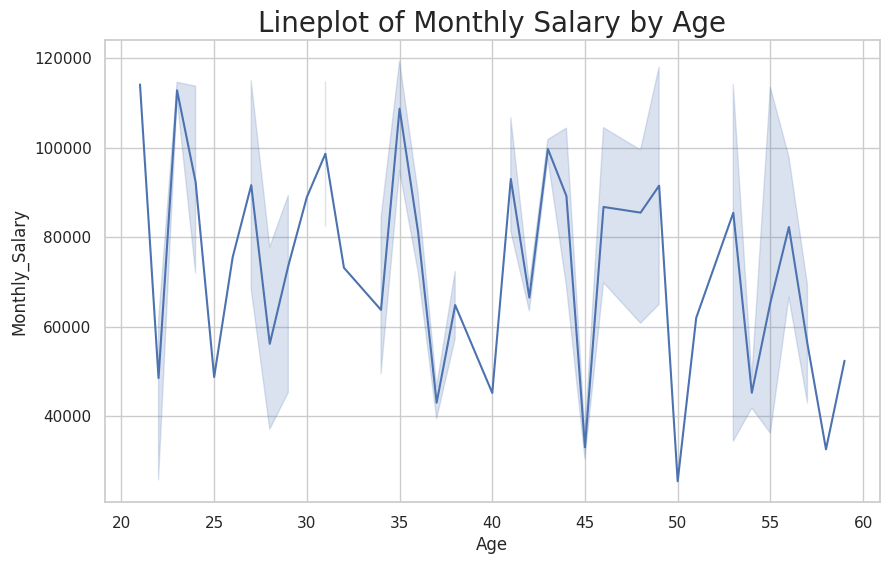

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.lineplot(data=df , x='Age' ,y='Monthly_Salary',palette='pastel')
plt.title('Lineplot of Monthly Salary by Age',fontsize=20)
plt.xlabel('Age',fontsize=12)
plt.ylabel('Monthly_Salary',fontsize=12)

In [ ]:
df['Department_imputed_mode']=df['Department'].fillna(df['Department']).mode()

/tmp/ipykernel_5235/289700552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df , x='Employee_ID' ,y='Age',palette='pastel')


Text(0, 0.5, 'Age')

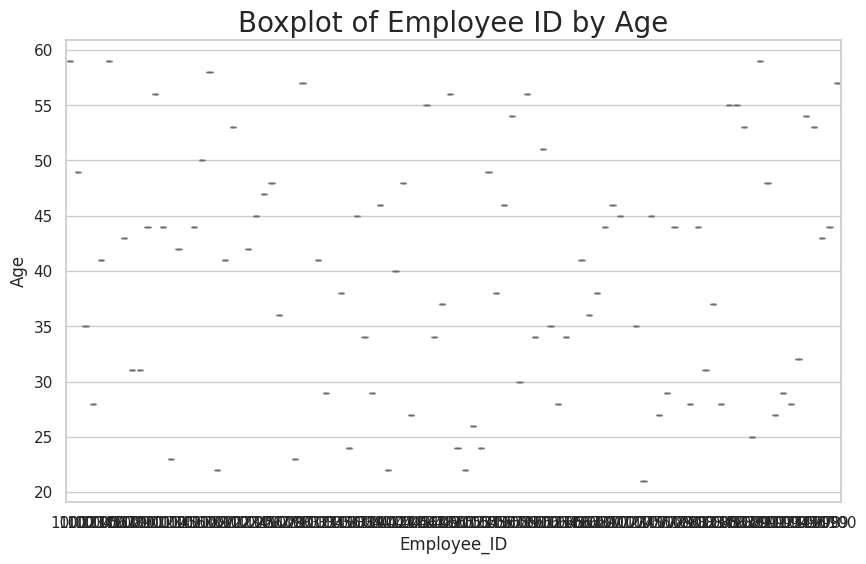

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.boxplot(data=df , x='Employee_ID' ,y='Age',palette='pastel')
plt.title('Boxplot of Employee ID by Age',fontsize=20)
plt.xlabel('Employee_ID',fontsize=12)
plt.ylabel('Age',fontsize=12)

/tmp/ipykernel_5235/1674079454.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df , x='Employee_ID' ,y='Age',palette='pastel')


Text(0, 0.5, 'Age')

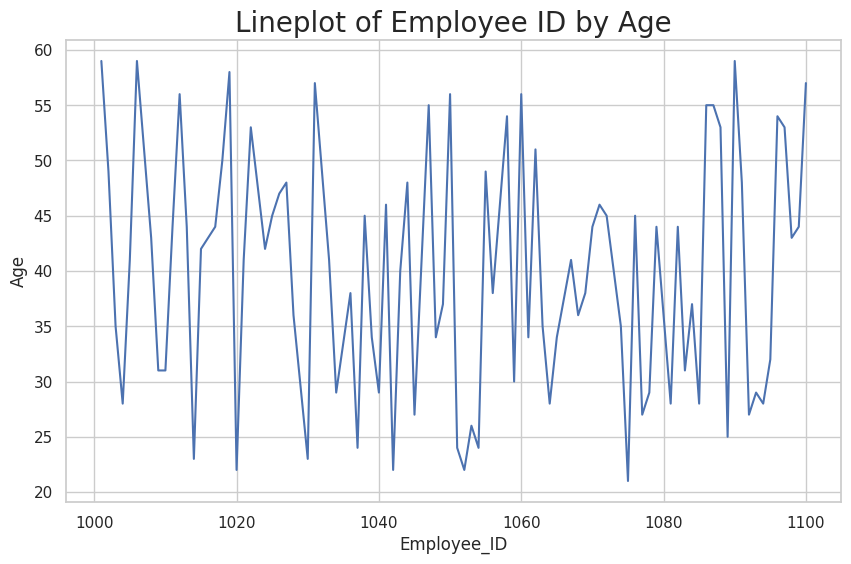

In [19]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
sns.lineplot(data=df , x='Employee_ID' ,y='Age',palette='pastel')
plt.title('Lineplot of Employee ID by Age',fontsize=20)
plt.xlabel('Employee_ID',fontsize=12)
plt.ylabel('Age',fontsize=12)

In [26]:
from sklearn.preprocessing import LabelEncoder
encoded_data=df.copy()
label_encoder = LabelEncoder()
encoded_data['Gender_Label'] = label_encoder.fit_transform(encoded_data['Gender'])
one_hot_encoded = pd.get_dummies(encoded_data['Department'], prefix='Department')
encoded_data=pd.concat([encoded_data, one_hot_encoded],axis=1)
Performance_Rating_mapping = {1:'First',2: 'Second',3:'Third',4:'Fourth',5:'Fifth'}
encoded_data['Performance_Rating_cat'] = encoded_data['Performance_Rating'].map(Performance_Rating_mapping)
print(encoded_data[['Gender','Gender_Label','Department','Performance_Rating','Performance_Rating_cat']].head())

   Gender  Gender_Label Department  Performance_Rating Performance_Rating_cat
0    Male             1         HR                   5                  Fifth
1  Female             0  Marketing                   2                 Second
2  Female             0         HR                   1                  First
3  Female             0         HR                   2                 Second
4    Male             1         IT                   3                  Third


In [27]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

In [28]:
#select numerical columns for scaling
numerical_columns = ['Age','Monthly_Salary','Performance_Rating']

In [29]:
#drop rows with missing values for simplicity
encoded_data.dropna(subset=numerical_columns, inplace=True)

In [33]:
#initialize the scalers
minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()

In [37]:
encoded_data['Age_MinMax']=minmax_scaler.fit_transform(encoded_data[['Age']])
encoded_data['Monthly_Salary_MinMax']=minmax_scaler.fit_transform(encoded_data[['Monthly_Salary']])
encoded_data['Performance_Rating']=minmax_scaler.fit_transform(encoded_data[['Performance_Rating']])

In [36]:
#apply standard scaling
encoded_data['Age_Standard'] = standard_scaler.fit_transform(encoded_data[['Age']])
encoded_data['Monthly_Salary_Standard'] = standard_scaler.fit_transform(encoded_data[['Monthly_Salary']])
encoded_data['Performance_Rating'] = standard_scaler.fit_transform(encoded_data[['Performance_Rating']])